# Model Comparison
Compare embeddings, classifiers, fine-tuned transformer, tuned tabular fusion, and ensemble outputs.

In [25]:
import json
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style='whitegrid')
proc = Path('../data/processed')
print('Using processed dir:', proc.resolve())

Using processed dir: C:\Users\vinib\OneDrive\Desktop\CSCE 676\Project\data\processed


## Embedding x Classifier Benchmark

In [26]:
bench_path = proc / 'embedding_classifier_model_comparison.csv'
if not bench_path.exists():
    print('Missing file:', bench_path)
    print('Run: python scripts/10_embedding_benchmark.py')
    bench = pd.DataFrame()
else:
    bench = pd.read_csv(bench_path)
    display(bench.sort_values(['setting','variant','f1'], ascending=[True, True, False]).head(25))

,embedding,classifier,setting,variant,accuracy,precision,recall,f1,roc_auc
36,bert_base,linear_svm,fixed_split_train_test,text_only,0.630624,0.568218,0.640145,0.602041,0.675303
32,bert_base,logistic_regression,fixed_split_train_test,text_only,0.629045,0.566828,0.636528,0.599659,0.675285
0,tfidf,logistic_regression,fixed_split_train_test,text_only,0.615627,0.551724,0.636528,0.591100,0.652742
4,tfidf,linear_svm,fixed_split_train_test,text_only,0.612470,0.547988,0.640145,0.590492,0.653112
44,bert_base,gradient_boosting,fixed_split_train_test,text_only,0.599842,0.534954,0.636528,0.581338,0.653520
20,minilm,linear_svm,fixed_split_train_test,text_only,0.615627,0.554455,0.607595,0.579810,0.641728
16,minilm,logistic_regression,fixed_split_train_test,text_only,0.612470,0.551155,0.603978,0.576359,0.644050
28,minilm,gradient_boosting,fixed_split_train_test,text_only,0.599053,0.536116,0.603978,0.568027,0.640127
12,tfidf,gradient_boosting,fixed_split_train_test,text_only,0.581689,0.518699,0.576854,0.546233,0.627750
8,tfidf,random_forest,fixed_split_train_test,text_only,0.595896,0.550617,0.403255,0.465553,0.637607


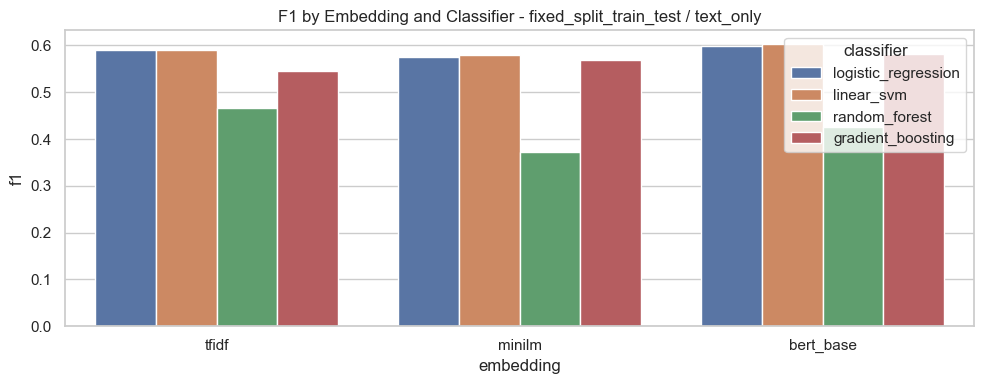

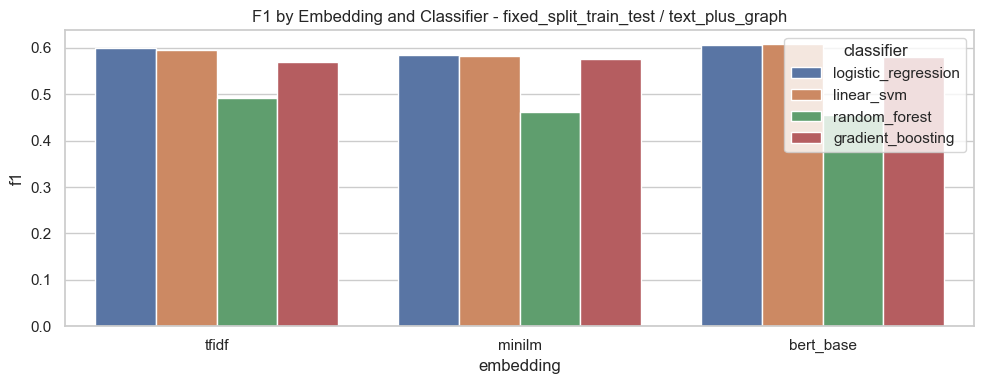

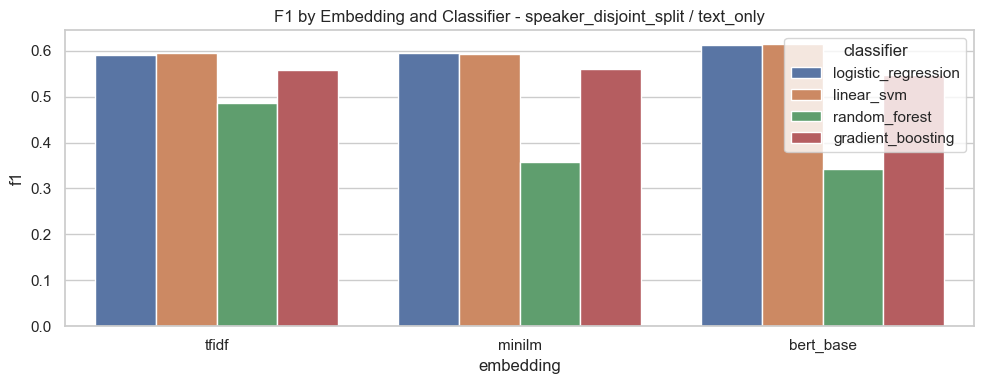

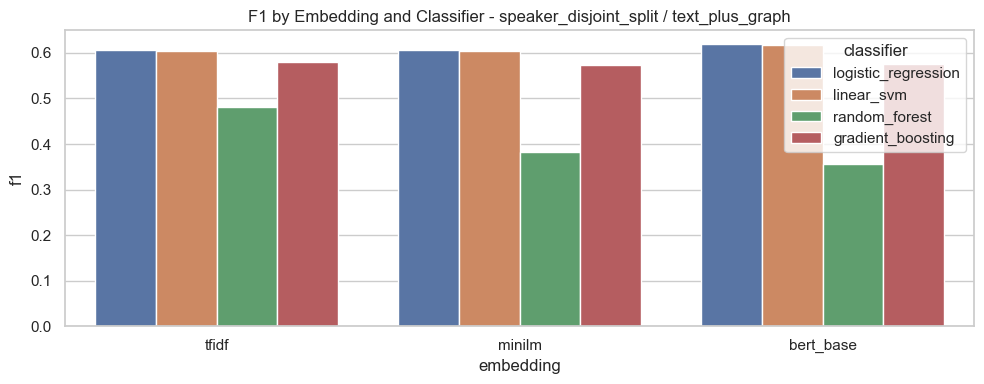

In [27]:
if bench.empty:
    print('Benchmark table empty; skipping plots.')
else:
    for setting in bench['setting'].unique():
        for variant in bench['variant'].unique():
            sub = bench[(bench['setting'] == setting) & (bench['variant'] == variant)].copy()
            if sub.empty:
                continue
            plt.figure(figsize=(10,4))
            sns.barplot(data=sub, x='embedding', y='f1', hue='classifier')
            plt.title(f'F1 by Embedding and Classifier - {setting} / {variant}')
            plt.tight_layout()
            plt.show()

## Fine-Tuned Transformer

In [30]:
paths = sorted(proc.glob('transformer_finetune_metrics_*.json'))
rows = []
for p in paths:
    payload = json.loads(p.read_text())
    tag = p.stem.replace('transformer_finetune_metrics_', '')
    for setting in ['fixed_split_train_test', 'speaker_disjoint_split']:
        if setting in payload:
            r = {'model_tag': tag, 'setting': setting}
            r.update(payload[setting])
            rows.append(r)
tr_df = pd.DataFrame(rows)
if tr_df.empty:
    print('No transformer metrics found. Run: python scripts/11_finetune_transformer.py --model-name bert-base-uncased')
else:
    display(tr_df.sort_values(['setting','f1'], ascending=[True, False]))

,model_tag,setting,accuracy,precision,recall,f1,roc_auc
0,bert-base-uncased,fixed_split_train_test,0.642463,0.602459,0.531646,0.564841,0.688777
1,bert-base-uncased,speaker_disjoint_split,0.641132,0.660000,0.490209,0.562573,0.684365


## Tuned Tabular Fusion

In [31]:
paths = sorted(proc.glob('tuned_tabular_fusion_metrics_*.json'))
rows = []
for p in paths:
    payload = json.loads(p.read_text())
    tag = p.stem.replace('tuned_tabular_fusion_metrics_', '')
    for setting in ['fixed_split_train_test', 'speaker_disjoint_split']:
        if setting in payload:
            r = {'text_tag': tag, 'setting': setting}
            r.update(payload[setting])
            rows.append(r)
tab_df = pd.DataFrame(rows)
if tab_df.empty:
    print('No tuned tabular metrics found. Run: python scripts/12_tuned_tabular_fusion.py --text-file text_embeddings_sentence_bert-base-uncased.parquet')
else:
    display(tab_df.sort_values(['setting','f1'], ascending=[True, False]))

,text_tag,setting,accuracy,precision,recall,f1,roc_auc
0,text_embeddings_sentence_bert-base-uncased,fixed_split_train_test,0.732439,0.722917,0.627486,0.671830,0.806021
1,text_embeddings_sentence_bert-base-uncased,speaker_disjoint_split,0.703433,0.714734,0.615800,0.661589,0.794068


## Ensemble + Threshold Optimization

In [32]:
ens_path = proc / 'ensemble_threshold_metrics.json'
if not ens_path.exists():
    print('Missing ensemble metrics. Run: python scripts/13_probability_ensemble.py')
else:
    ensemble = json.loads(ens_path.read_text())
    rows = []
    for setting, v in ensemble.items():
        r = {'setting': setting, 'threshold': v.get('threshold'), 'tune_f1': v.get('tune_f1')}
        r.update(v.get('eval_metrics', {}))
        rows.append(r)
    display(pd.DataFrame(rows))

,setting,threshold,tune_f1,accuracy,precision,recall,f1,roc_auc
0,fixed_split_train_test,0.575,0.643204,0.616379,0.553633,0.765550,0.642570,0.682841
1,speaker_disjoint_split,0.400,0.697071,0.561162,0.482873,0.804788,0.603591,0.677647


## Hypothesis Check
- H1: In fixed split, compare text-only vs text+graph in benchmark table.
- H2: In speaker-disjoint split, compare same gap for robustness.
- H3: Compare best benchmark row vs transformer/tuned-tabular/ensemble metrics.